In [55]:
import os
import json
from datasets import load_dataset as _hf_load_dataset


#DATASET_PATH = r"C:\Users\ovill\OneDrive\Documentos\Donut\Ejercicio Sintetico 3\scotia_synth_fix"
DATASET_PATH = r"C:\Users\ovill\OneDrive\Documentos\Donut Real Data\Pre entreno\Datos Sinteticos\Plantillas\scotia_synth_fix"

from datasets import load_dataset


# Hugging Face detecta automáticamente train/test si existen
dataset = load_dataset(
    path=DATASET_PATH,
    data_dir=DATASET_PATH,
    trust_remote_code=True
)


In [56]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 4500
    })
    validation: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 500
    })
})

In [3]:
ignore_id = -100
task_start_token = "<parsing>"
new_special_tokens = []

new_special_tokens.extend([task_start_token])

In [4]:
class DataProcessor:
    def __init__(self):
        self.new_special_tokens = set()
    
    def clear_new_special_tokens(self):
        self.new_special_tokens = set()
    
    def get_new_special_tokens(self):
        return list(self.new_special_tokens)

    def json2token(self, obj, update_special_tokens_for_json_key: bool = False, sort_json_key: bool = True):
        """
        Convert an ordered JSON object into a token sequence
        """
        
        if type(obj) == dict:
            if len(obj) == 1 and "text_sequence" in obj:
                return obj["text_sequence"]
            else:
                output = ""
                if sort_json_key:
                    keys = sorted(obj.keys(), reverse=True)
                else:
                    keys = obj.keys()
                for k in keys:
                    if update_special_tokens_for_json_key:
                        self.new_special_tokens.add(fr"<s_{k}>")
                        self.new_special_tokens.add(fr"</s_{k}>")
                    # xml style string
                    json_string = self.json2token(obj[k],update_special_tokens_for_json_key, sort_json_key)
                    output += ( fr"<s_{k}>" + json_string + fr"</s_{k}>")
                return output
        
        elif type(obj) == list:
            json_strings = []
            for item in obj:
                json_string = self.json2token(item, update_special_tokens_for_json_key, sort_json_key)
                json_strings.append(json_string)
            output = r"<sep/>".join(json_strings)
            return output
        
        else:
            return str(obj)

In [5]:
data_processor = DataProcessor()
json2token = data_processor.json2token

example_vqa_gt = [
    {"question" : "what is the model name?", "answer" : "donut"},
     {"question" : "what is the model name?", "answer" : "document understanding transformer"}
    ] #gt_parses
example_document_classification_gt = {"class" : "scientific_report"} #gt_parse
example_doc_parsing_gt ={
    "menu": [
      {
        "nm": "[MD] SOFT STEAMED CHEESEC",
        "cnt": "2",
        "price": "20,000"
      },
      {
        "nm": "[MD] SOFT STEAMED CHOCOCA",
        "cnt": "2",
        "price": "20,000"
      }
    ],
    "total": {
      "total_price": "40,000",
      "cashprice": "100,000",
      "changeprice": "60,000"
    }
  } #gt_parse

json2token(example_doc_parsing_gt)

'<s_total><s_total_price>40,000</s_total_price><s_changeprice>60,000</s_changeprice><s_cashprice>100,000</s_cashprice></s_total><s_menu><s_price>20,000</s_price><s_nm>[MD] SOFT STEAMED CHEESEC</s_nm><s_cnt>2</s_cnt><sep/><s_price>20,000</s_price><s_nm>[MD] SOFT STEAMED CHOCOCA</s_nm><s_cnt>2</s_cnt></s_menu>'

In [6]:
def clean_docs_for_donut(sample):
    gt = json.loads(sample["ground_truth"])
    parsed_text = gt['gt_parse'] if 'gt_parse' in gt else gt['gt_parses']
    text = json2token(parsed_text, update_special_tokens_for_json_key=True) # adds a new token for each key
    return {"text": text}

columns_to_remove = [ c for c in dataset['train'].column_names if c not in ['image', 'ground_truth', 'text']]

data_processor.clear_new_special_tokens()
proc_dataset = dataset.map(clean_docs_for_donut, remove_columns=columns_to_remove)
new_key_tokens = data_processor.get_new_special_tokens()

print(f"Sample:\n{proc_dataset['train'][4]['text']}")
# bos_token and eos_token will be added by data collator function

Map: 100%|██████████| 500/500 [00:00<00:00, 12656.85 examples/s]


Sample:
<s_totales><s_saldo_final>$1,096,317.16</s_saldo_final><s_retiros>$32,049.94</s_retiros><s_depositos>$262,444.22</s_depositos></s_totales><s_tabla>movimientos_scotia_like</s_tabla><s_movimientos><s_saldo>$862,436.29</s_saldo><s_retiro>$3,486.59</s_retiro><s_fecha>27 OCT</s_fecha><s_deposito></s_deposito><s_concepto>TAMALES POR CONCEPTO TAL CUENTA 80196591841</s_concepto><sep/><s_saldo>$861,120.18</s_saldo><s_retiro>$1,316.11</s_retiro><s_fecha>05 FEB</s_fecha><s_deposito></s_deposito><s_concepto>5100579825MAG 2105031W3MERPAGO TYQDONAMX REF 5863352601 AUT YNE21X CUENTA 10031114886</s_concepto><sep/><s_saldo>$917,358.77</s_saldo><s_retiro></s_retiro><s_fecha>18 AGO</s_fecha><s_deposito>$56,238.59</s_deposito><s_concepto>COMISION VENTAS DEBITO REF 7427966649 AUT 0HJNFX POR CONCEPTO ESA</s_concepto><sep/><s_saldo>$911,961.08</s_saldo><s_retiro>$5,397.69</s_retiro><s_fecha>12 JUL</s_fecha><s_deposito></s_deposito><s_concepto>SWEB TRANSF.INTERB SPEI BANORTE PAGO /93934839 16:35:28 20

In [7]:
import torch
import torch.nn as nn
from typing import Optional
from transformers import VisionEncoderDecoderModel


# copied from: https://github.com/huggingface/transformers/blob/main/src/transformers/loss/loss_utils.py
def fixed_cross_entropy(
    source: torch.Tensor,
    target: torch.Tensor,
    num_items_in_batch: Optional[torch.Tensor] = None,
    ignore_index: int = -100,
    **kwargs,
) -> torch.Tensor:
    reduction = "sum" if num_items_in_batch is not None else "mean"
    loss = nn.functional.cross_entropy(source, target, ignore_index=ignore_index, reduction=reduction)
    if reduction == "sum":
        # just in case users pass an int for num_items_in_batch, which could be the case for custom trainer
        if torch.is_tensor(num_items_in_batch):
            num_items_in_batch = num_items_in_batch.to(loss.device)
        loss = loss / num_items_in_batch
    return loss

def ForCausalLMLoss(
    logits,
    labels,
    vocab_size: int,
    num_items_in_batch: Optional[torch.Tensor] = None
) -> torch.Tensor:
    # Upcast to float if we need to compute the loss to avoid potential precision issues
    logits = logits.float()

    # no need to shift labels
    # VisionEncoderDecoderModel shifts to right before feeding to forward method
    # https://github.com/huggingface/transformers/blob/37152f84464dea9086dd1d88cd58f63c2129ee69/src/transformers/models/vision_encoder_decoder/modeling_vision_encoder_decoder.py#L412

    # Flatten the tokens
    logits = logits.view(-1, vocab_size)
    labels = labels.view(-1)
    # Enable model parallelism
    labels = labels.to(logits.device)
    loss = fixed_cross_entropy(logits, labels, num_items_in_batch)
    return loss

class DonutModel(VisionEncoderDecoderModel):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_function = ForCausalLMLoss

# https://github.com/huggingface/transformers/blob/071eb5334f5a9ac2c7a13515219be8a272388ec6/src/transformers/models/vision_encoder_decoder/modeling_vision_encoder_decoder.py#L438C1-L443C14
class DonutVQAModel(DonutModel):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.config.prompt_end_token_id = None
        causal_lm_loss = self.loss_function

        def vqa_loss_function(logits, labels, vocab_size: int, num_items_in_batch: Optional[torch.Tensor] = None):
                """ignores all losses before and including the prompt_end_token_id"""
                # Get the indices of the prompt_end_token_id for each row
                prompt_end_token_id = self.config.decoder_start_token_id if self.config.prompt_end_token_id is None else self.config.prompt_end_token_id
                prompt_end_indices = torch.argmax((labels == prompt_end_token_id).int(), dim=1)
                # Iterate through each row and apply the masking
                for i in range(labels.shape[0]):
                    labels[i, :prompt_end_indices[i]+1] = -100
                return causal_lm_loss(logits, labels, vocab_size, num_items_in_batch)
        self.loss_function = vqa_loss_function

In [8]:
import torch
from transformers import DonutProcessor, VisionEncoderDecoderConfig

ckpt = 'naver-clova-ix/donut-base'
processor = DonutProcessor.from_pretrained(ckpt)
model = DonutModel.from_pretrained(ckpt)

len(processor.tokenizer)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


57525

In [9]:

new_special_tokens = list(set(new_special_tokens + new_key_tokens))

print(f"New special tokens:  {new_special_tokens}")

# add new special tokens to tokenizer
print(f"Adding {len(new_special_tokens)} special tokens")
processor.tokenizer.add_special_tokens({"additional_special_tokens": new_special_tokens})

# https://x.com/karpathy/status/1621578354024677377?lang=en
multiplier = 64
if len(processor.tokenizer) % multiplier != 0:
  extra_token_count = multiplier - (len(processor.tokenizer) % multiplier)
  print(f"Adding {extra_token_count} fake tokens")
  fake_tokens = [f"<reserved_{i+1}>" for i in range(extra_token_count)]
  processor.tokenizer.add_tokens(fake_tokens)

print(f"New tokenizer length: {len(processor.tokenizer)}")


New special tokens:  ['<s_depositos>', '</s_totales>', '<s_totales>', '<s_retiro>', '<s_tabla>', '<s_deposito>', '</s_concepto>', '<s_saldo>', '</s_movimientos>', '</s_saldo_final>', '</s_tabla>', '</s_retiros>', '</s_retiro>', '<s_retiros>', '<s_movimientos>', '<s_fecha>', '<parsing>', '<s_saldo_final>', '<s_concepto>', '</s_saldo>', '</s_fecha>', '</s_depositos>', '</s_deposito>']
Adding 23 special tokens
Adding 52 fake tokens
New tokenizer length: 57600


In [10]:
# to find max_token to output during training
def add_token_count(example):
  example['tokens_count'] = processor.tokenizer(
      example['text'],
      add_special_tokens=True,
      return_tensors="pt",
  ).input_ids[0].shape[0]
  return example

proc_dataset = proc_dataset.map(add_token_count)
max_length = max(proc_dataset['train']['tokens_count'])
print('maximum length of example:', max_length)


Map: 100%|██████████| 500/500 [00:00<00:00, 1023.37 examples/s]

maximum length of example: 1303


In [11]:
max_length = 1500
processor_image_size = [1280 , 1792]#[720, 960] # (width, height)

## UPDATE: processor
processor.image_processor.size['width'] = processor_image_size[0]
processor.image_processor.size['height'] = processor_image_size[1]
processor.image_processor.do_align_long_axis = False # don't rotate image if height is greater than width

## UPDATE: model

# generation config
model.config.decoder.max_length = max_length
model.config.pad_token_id = processor.tokenizer.pad_token_id
# ⚠️ IMPORTANT: set decoder_start_token
task_token_id = processor.tokenizer.encode(task_start_token, add_special_tokens=False)[0]
task_token_id
model.config.decoder_start_token_id = task_token_id

# Resize embedding layer to match vocabulary size
new_emb = model.decoder.resize_token_embeddings(len(processor.tokenizer))

# Adjust our image size and output sequence lengths
model.config.encoder.image_size = processor_image_size[::-1] # (height, width)

print(f"New token embedding size: {new_emb}")

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


New token embedding size: MBartScaledWordEmbedding(57600, 1024, padding_idx=1)


In [12]:
def prepare_data(examples):
    images = [e['image'].convert("RGB") for e in examples]
    texts = [e['text'] for e in examples]
    # create tensor from image
    pixel_values = processor(
        images,
        return_tensors="pt"
        ).pixel_values
    # tokenize text
    input_ids = processor.tokenizer(
        texts,
        add_special_tokens=True, # add <s> and </s>
        max_length=max_length,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    ).input_ids
    labels = input_ids.clone()
    # ignore pad tokens when calculating `loss`
    labels[labels == processor.tokenizer.pad_token_id] = ignore_id
    return {"pixel_values": pixel_values, "labels": labels}

# TEST
batch= prepare_data([
    proc_dataset['train'][5],
])
batch.keys(), batch['pixel_values'].shape, batch['labels'].shape

(dict_keys(['pixel_values', 'labels']),
 torch.Size([1, 3, 1792, 1280]),
 torch.Size([1, 1500]))

In [49]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

save_model_name = "donut-base-finetuned-scotia_1"

# Arguments for training
training_args = Seq2SeqTrainingArguments(
    output_dir=save_model_name,
    num_train_epochs=3,
    max_steps = 1000,
    learning_rate=2e-5,
    per_device_train_batch_size=1,
    per_device_eval_batch_size =1,
    weight_decay=0.01,
    fp16=True,
    logging_steps=100,
    eval_strategy="no",
    save_strategy="epoch",
    save_total_limit=1,
    # group_by_length=True,
    predict_with_generate=True,
    # push to hub parameters
    report_to="tensorboard",
    push_to_hub=False,
    hub_strategy="every_save",
    hub_model_id=save_model_name,
    remove_unused_columns=False
)

# Create Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    data_collator=prepare_data,
    train_dataset=proc_dataset["train"],
    eval_dataset=proc_dataset["validation"],
)

In [50]:
# Start training
trainer.train()

Step,Training Loss
100,0.119800
200,0.109600
300,0.097500
400,0.089800
500,0.085000
600,0.082000
700,0.083900
800,0.084200
900,0.085500
1000,0.087900


TrainOutput(global_step=1000, training_loss=0.09253116893768311, metrics={'train_runtime': 403.0532, 'train_samples_per_second': 2.481, 'train_steps_per_second': 2.481, 'total_flos': 5.83690174857216e+18, 'train_loss': 0.09253116893768311, 'epoch': 0.2222222222222222})

In [51]:
import re
import torch
from transformers import DonutProcessor, VisionEncoderDecoderConfig

# ckpt = "/content/donut-base-finetuned-sroie"
ckpt = "hf-tuner/donut-base-finetuned-sroie"

#config = VisionEncoderDecoderConfig.from_pretrained(ckpt)
#processor = DonutProcessor.from_pretrained(ckpt)
device = "cuda" if torch.cuda.is_available() else "cpu"
#config.dtype = torch.float16 if torch.cuda.is_available() else torch.float32

#model = DonutModel.from_pretrained(ckpt, config=config)
model.to(device)


DonutModel(
  (encoder): DonutSwinModel(
    (embeddings): DonutSwinEmbeddings(
      (patch_embeddings): DonutSwinPatchEmbeddings(
        (projection): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): DonutSwinEncoder(
      (layers): ModuleList(
        (0): DonutSwinStage(
          (blocks): ModuleList(
            (0): DonutSwinLayer(
              (layernorm_before): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
              (attention): DonutSwinAttention(
                (self): DonutSwinSelfAttention(
                  (query): Linear(in_features=128, out_features=128, bias=True)
                  (key): Linear(in_features=128, out_features=128, bias=True)
                  (value): Linear(in_features=128, out_features=128, bias=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                )
              

In [41]:
# inference (generation)
sample = dataset['validation'][10]

pixel_values = processor(sample['image'],return_tensors="pt").pixel_values.to(device)

task_start_token = "<parsing>"
decoder_input_ids = processor.tokenizer(task_start_token, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

generated_ids = model.generate(pixel_values,
                               decoder_input_ids=decoder_input_ids,
                               max_length=max_length,
                               bad_words_ids=[[processor.tokenizer.unk_token_id]]
                               )

print(f'generated tokens count: {len(generated_ids[0])}')
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
print(generated_text)
movs = processor.token2json(generated_text)

generated tokens count: 1133
<parsing><s><s_iitcdip><s_totales> $677,033.24</s_saldo_final><s_retiros> $637,840.70</s_saldo_final><s_retiros> $31,634,296.87</s_depositos></s_totales><s_tabla> movimientos_scotia_like</s_tabla><s_movimientos><s_movimientos><s_movimientos><s_movimientos><s_saldo> $465,144.93</s_saldo><s_retiro> $1,621.95</s_retiro><s_fecha> 17 FEB</s_fecha><s_deposito></s_deposito><s_concepto> VENTAS CREDITO 144778001 TERMINALES PUNTO DE VENTA REF 7971411074 AUT 7F9WGX</s_concepto><sep/><s_saldo> $464,745.33</s_saldo><s_retiro> $399.60</s_retiro><s_fecha> 24 ENE</s_fecha><s_deposito></s_deposito><s_concepto> SEC DE FIN DEL GOB D REF:2508012706341632480 CIE:0846074 REF 0716877753 AUT YJJ4YN</s_concepto><sep/><s_saldo> $479,925.44</s_saldo><s_retiro></s_retiro><s_fecha> 04 MAR</s_fecha><s_deposito> $15,180.11</s_deposito><s_concepto> PAGO DE CAPITAL 0898108638 REF 2446902017 REF U6BGCG CUENTA 189708988013</s_concepto><sep/><s_saldo> $478,723.35</s_saldo><s_retiro> $1,202.09

In [52]:
# inference (generation)
sample = dataset['validation'][10]

pixel_values = processor(sample['image'],return_tensors="pt").pixel_values.to(device)

task_start_token = "<parsing>"
decoder_input_ids = processor.tokenizer(task_start_token, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

generated_ids = model.generate(pixel_values,
                               decoder_input_ids=decoder_input_ids,
                               max_length=max_length,
                               bad_words_ids=[[processor.tokenizer.unk_token_id]]
                               )

print(f'generated tokens count: {len(generated_ids[0])}')
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
print(generated_text)
movs = processor.token2json(generated_text)


generated tokens count: 1124
<parsing><s><s_totales><s_saldo_final> $677,033.24</s_saldo_final><s_retiros> $40,826.77</s_retiros><s_depositos> $358,840.91</s_depositos></s_totales><s_tabla> movimientos_scotia_like</s_tabla><s_movimientos><s_saldo> $465,144.93</s_saldo><s_retiro> $1,621.95</s_retiro><s_fecha> 17 FEB</s_fecha><s_deposito></s_deposito><s_concepto> VENTAS CREDITO 144778001 TERMINALES PUNTO DE VENTA REF 7971411074 AUT 7F9WGX</s_concepto><sep/><s_saldo> $464,745.33</s_saldo><s_retiro> $399.60</s_retiro><s_fecha> 24 ENE</s_fecha><s_deposito></s_deposito><s_concepto> SEC DE FIN DEL GOB D REF:2508012706341632525 CIE:0846074 REF 0716877753 AUT YIJIJYN</s_concepto><sep/><s_saldo> $479,925.44</s_saldo><s_retiro></s_retiro><s_fecha> 04 MAR</s_fecha><s_deposito> $15,180.11</s_deposito><s_concepto> PAGO DE CAPITAL 089810638 REF 2446902017 REF U6BGCG CUENTA 18970898013</s_concepto><sep/><s_saldo> $478,723.35</s_saldo><s_retiro> $1,202.09</s_retiro><s_fecha> 15 JUN</s_fecha><s_deposito

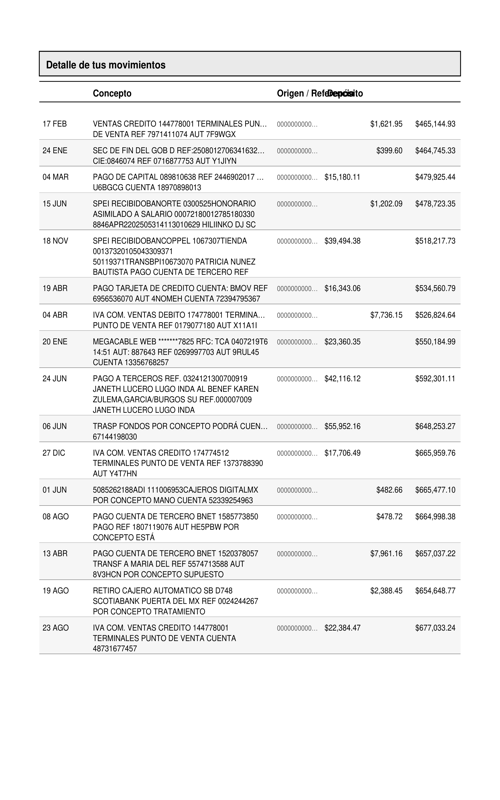

In [53]:
sample['image'].resize((500,800))

In [54]:
movs

{'totales': {'saldo_final': '$677,033.24',
  'retiros': '$40,826.77',
  'depositos': '$358,840.91'},
 'tabla': 'movimientos_scotia_like',
 'movimientos': [{'saldo': '$465,144.93',
   'retiro': '$1,621.95',
   'fecha': '17 FEB',
   'deposito': '',
   'concepto': 'VENTAS CREDITO 144778001 TERMINALES PUNTO DE VENTA REF 7971411074 AUT 7F9WGX'},
  {'saldo': '$464,745.33',
   'retiro': '$399.60',
   'fecha': '24 ENE',
   'deposito': '',
   'concepto': 'SEC DE FIN DEL GOB D REF:2508012706341632525 CIE:0846074 REF 0716877753 AUT YIJIJYN'},
  {'saldo': '$479,925.44',
   'retiro': '',
   'fecha': '04 MAR',
   'deposito': '$15,180.11',
   'concepto': 'PAGO DE CAPITAL 089810638 REF 2446902017 REF U6BGCG CUENTA 18970898013'},
  {'saldo': '$478,723.35',
   'retiro': '$1,202.09',
   'fecha': '15 JUN',
   'deposito': '',
   'concepto': 'SPEI RECIBIDOBANORTE 0300525HONORARIO ASIMILADO A SLARIO 00072180012785180330 8846APR220250531413010629 HILINKO DJ SC'},
  {'saldo': '$518,217.73',
   'retiro': '',
  

In [38]:
from PIL import Image
image = Image.open(r"C:\Users\ovill\OneDrive\Escritorio\borrar\k1.jpg").convert("RGB")

    # 2) Procesarla
pixel_values = processor(
        image, return_tensors="pt"
    ).pixel_values.to(device)

In [39]:

task_start_token = "<parsing>"
decoder_input_ids = processor.tokenizer(task_start_token, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

generated_ids = model.generate(pixel_values,
                               decoder_input_ids=decoder_input_ids,
                               max_length=max_length,
                               bad_words_ids=[[processor.tokenizer.unk_token_id]]
                               )

print(f'generated tokens count: {len(generated_ids[0])}')
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
print(generated_text)
movs = processor.token2json(generated_text)

generated tokens count: 1500
<parsing><s> 160.71</s_saldo_final><s_retiros> $38,713.71</s_saldo_final>phan $110,376.76</s_retiros>.19.19.19.19</s_depositos></s_totales><s_tabla> ROCKTIALINE</s_concepto> $120.75</s_saldo><s_retiro> $2,120.75</s_saldo><s_retiro> $2,000.00</s_retiro><s_fecha> $120.75</s_saldo_final><s_fecha> $31,781.71</s_saldo><s_fecha> $2,129.75</s_saldo><s_retiro><s_fecha> $2,120.75</s_saldo><s_deposito></s_retiro><s_fecha> $20,000.00</s_retiro><s_fecha> DWEB DISPOSICIONES CONSCOTIALINE有著多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣,018.71</s_saldo><s_retiro> $60,600.96</s_concepto><s_fecha> mineral $68,016.71</s_saldo><s_retiro><s_fecha>多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣多樣

In [40]:
movs

{'retiros': '$38,713.71</s_saldo_final>phan $110,376.76'}

### Domain Shift 

In [33]:
DATASET_PATH = r"C:\Users\ovill\OneDrive\Documentos\Donut\Ejercicio Sintetico 2\bbva_synth_es"
from datasets import load_dataset


# Hugging Face detecta automáticamente train/test si existen
dataset_2 = load_dataset(
    path=DATASET_PATH,
    data_dir=DATASET_PATH,
    trust_remote_code=True
)